In [2]:
from collections import Counter
from linear_algebra import distance
from functools import reduce
import math, random

In [3]:
def vector_subtract(v, w):
    """subtracts two vectors componentwise"""

def scalar_multiply(c, v):
    return [c * v_i for v_i in v]


#### Sum of Squares

In [6]:
def sum_of_squares(v):
    """ computes the sum of squared elements in v """
    return sum(v_i ** 2 for v_i in v)

#### Estimating the Gradient

In [17]:
def difference_quotient(f, x, h):
    return (f(x+h) - f(x)) / h

def square(x):
    return x * x

def derivative(x):
    return 2 * x

In [18]:
derivative_estimate = lambda x: difference_quotient(square,
                                                    x,
                                                    h=0.00001)

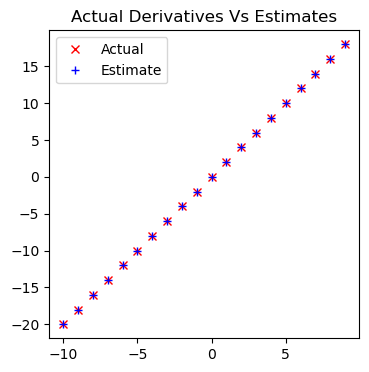

In [26]:
import matplotlib.pyplot as plt
x = range(-10,10)
plt.figure(figsize=(4,4))
plt.plot(x, list(map(derivative, x)), 'rx', label='Actual')
plt.plot(x, list(map(derivative_estimate, x)), 'b+', label='Estimate')
plt.title('Actual Derivatives Vs Estimates')
plt.legend()
plt.show()

#### Partial Difference Quotient

In [28]:
def partial_difference_quotient(f, v, i, h):
    w = [v_j + (h if j== i else 0)
         for j, v_j in enumerate(v)]
    return (f(w) - f(v)) / h

def estimate_gradient(f, v, h=0.00001):
    return [partial_difference_quotient(f, v, i, h)
            for i, _ in ennumerate(v)]

#### Using the Gradient

In [30]:
def step(v, direction, step_size):
    """ move step_size in the direction from v """
    return [v_i + step_size * direction_i
            for v_i, direction_i in zip(v, direction)]

def sum_of_squares_gradient(v):
    return [2 * v_i for v_i in v]

In [37]:

v = [random.randint(-10,10) for i in range(3)]
tolerance = 0.0000001

while True:
    gradient = sum_of_squares_gradient(v)
    next_v = step(v, gradient, -0.01)
    if distance(next_v, v) < tolerance:
        break
    v = next_v

print(v)

[2.4084880892653316e-06, -4.816976178530657e-07, -4.335278560677595e-06]


#### Choosing the Right Step Size

In [38]:
step_sizes = [100, 10, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]

In [39]:
def safe(f):
    """ define a new function that wraps f and return it """
    def safe_f(*args, **kwargs):
        try:
            return f(*args, **kwargs)
        except:
            return float('inf')
    return safe_f

#### Minimize / Maximize Breach

In [43]:
def minimize_batch(target_fn, gradient_fn, theta_0, toleranc=0.000001):
    """ Use gradient descent to find theta that minimizes target function """
    step_sizes = [100, 10, 1, 0.1, 0.01, 0.001, 0.0001, 0.00001]
    theta = theta_0
    target_fn = safe(target_fn)
    value = target_fn(theta)

    while True:
        gradient = gradient_fn(theta)
        next_thetas = [step(theta, gradient, -step_size)
                       for step_size in step_sizes]
        next_theta = min(next_thetas, key=target_fn)
        next_value = target_fn(next_theta)
        if abs(value - next_value) < tolerance:
            return theta
        else:
            theta, value = next_theta, next_value

def negate(f):
    """ return a function that for any input x returns -f(x) """
    return lambda *args, **kwargs: -f(*args, **kwargs)

def negate_all(f):
    """ the same when f returns a list of numbers """
    return lambda *args, **kwargs: [-y for y in f(*args, **kwargs)]

def maximize_batch(target_fn, gradient_fn, theta_0, tolerance=0.000001):
    return minimize_batch(negate(target_fn),
                          negate_all(gradient_fn),
                          theta_0,
                          tolerance)

In [44]:
print("using minimize_batch")

v = [random.randint(-10,10) for i in range(3)]

v = minimize_batch(sum_of_squares, sum_of_squares_gradient, v)

print("minimum v", v)
print("minimum value", sum_of_squares(v))

using minimize_batch
minimum v [-0.00027875931498163285, -0.0003484491437270411, 0.00013937965749081642]
minimum value 2.1855025037539464e-07


#### Stochastic Gradient Descent

In [46]:
def in_random_order(data):
    """ generator that returns the elements of data in random order """
    indexes = [i for i, _ in enumerate(data)]
    random.shuffle(indexes)
    for i in indexes:
        yield data[i]

def minimize_stochatic(target_fn, gradient_fn, x, y, theta_0, alpha_0=0.01):
    data = list(zip(x,y))
    theta = theta_0
    alpha = alpha_0
    min_theta, min_value = None, float("inf")
    iterations_with_no_improvement = 0
    while iterations_with_no_improvement < 100:
        value = sum(target_fn(x_i, y_i, theta) for x_i, y_i in data)
        if value < min_value:
            min_theta, min_value = theta, value
            iterations_with_no_improvement = 0
            alpha = alpha_0
        else:
            iterations_with_no_improvement +=1
            alpha *=0.9
        for x_i, y_i in in_random_order(data):
            gradient_i = gradient_fn(x_i, y_i, theta)
            theta = vector_substract(theta, scalar_multiply(alpha, gradient_i))
    return min_theta

In [47]:
def maximize_stochastic(target_fn, gradient_fn, x, y, theta_0, alpha_0=0.01):
    return minimize_stochastic(negate(target_fn),
                               negate_all(gradient_fn),
                               x, y, theta_0, alpha_0)